### Bài 3: Xây dựng kiến trúc Encoder-Decoder gồm 3 lớp LSTM cho module encoder và 3 lớp LSTM cho module decoder, với hidden size là 256, cho bài toán dịch máy từ tiếng Anh sang tiếng Việt. Module decoder được trang bị kỹ thuật attention theo mô tả của nghiên cứu "[Effective Approaches to Attention-based Neural Machine Translation](https://arxiv.org/abs/1508.04025)". Huấn luyện mô hình này trên bộ dữ liệu PhoMT sử dụng Adam làm phương thức tối ưu tham số. Đánh giá độ hiệu quả của mô hình sử dụn độ đo ROUGE-L.

In [128]:
!pip install -q rouge-score

In [129]:
# Import các thư viện cần thiết
import os
import sys
import json

import torch
from typing import List, Dict
import numpy as np

base_dir = os.getcwd()
# data_dir = os.path.join(base_dir, 'data', 'small_subset')
colab_dir = os.path.join(base_dir)

# Đọc train/dev/test small subset data
train_data = json.load(open(os.path.join(colab_dir, 'small-train.json'), 'r', encoding='utf-8'))
dev_data = json.load(open(os.path.join(colab_dir, 'small-dev.json'), 'r', encoding='utf-8'))
test_data = json.load(open(os.path.join(colab_dir, 'small-test.json'), 'r', encoding='utf-8'))

print("\nSample train:")
print(type(train_data))
print(train_data[0])


Sample train:
<class 'list'>
{'english': 'It begins with a countdown .', 'vietnamese': 'Câu chuyện bắt đầu với buổi lễ đếm ngược .'}


## 1. Tiền xử lý dữ liệu + TOKENIZE + BUILD VOCAB

In [130]:
import re

def clean_text(text: str):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)  # bỏ dấu câu
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [131]:
def tokenize(sentence: str):
    """
    Tokenize đơn giản: lowercase + split theo khoảng trắng
    """
    sentence = clean_text(sentence)
    return sentence.split()

In [132]:
print(tokenize("Hello, world! How are you?"))

['hello', 'world', 'how', 'are', 'you']


In [133]:
# Kiểm tra hàm tokenize theo split whitespace và lowercase
print(tokenize(train_data[0]["english"]))
print(tokenize(train_data[0]["vietnamese"]))

['it', 'begins', 'with', 'a', 'countdown']
['câu', 'chuyện', 'bắt', 'đầu', 'với', 'buổi', 'lễ', 'đếm', 'ngược']


### 1.1 Thu thập token từ toàn bộ train set

In [134]:
from collections import Counter

# Counter là một dict đặc biệt để đếm tần số xuất hiện của các phần tử trong một iterable
src_counter = Counter() # src: source language (English)
tgt_counter = Counter() # tgt: target language (Vietnamese)

for sample in train_data:
    src_tokens = tokenize(sample["english"])
    tgt_tokens = tokenize(sample["vietnamese"])

    # Cập nhật counter với các token từ câu hiện tại
    src_counter.update(src_tokens)
    tgt_counter.update(tgt_tokens)

print("Số token tiếng Anh (raw):", len(src_counter))
print("Số token tiếng Việt (raw):", len(tgt_counter))

Số token tiếng Anh (raw): 17252
Số token tiếng Việt (raw): 6883


In [135]:
print(src_counter.most_common(5))  # 10 token xuất hiện nhiều nhất trong tập tiếng Anh
print(tgt_counter.most_common(5))  # 10 token xuất hiện nhiều nhất trong tập tiếng Việt

[('the', 15553), ('and', 10979), ('to', 9490), ('of', 8577), ('a', 7837)]
[('và', 9062), ('tôi', 8797), ('là', 8127), ('có', 7399), ('một', 6995)]


### 1.2 Định nghĩa các special tokens

>`eos` đặc biệt cần thiết trong seq2seq khi đánh giá bằng ROUCE-L - vì không có nó, thành phần precision sẽ giảm mạnh do cố gắng sinh thừa từ.

>`bos` sẽ ảnh hưởng nhẹ hơn, nhưng vẫn cần có nó vì nếu không, timestep đầu rất dễ đoán sai, mà LSTM lại phụ thuộc rất nhiều vào hidden_state của step trước.

In [136]:
PAD_TOKEN = "<pad>" # padding 0, cho câu ngắn
BOS_TOKEN = "<bos>" # begin of sentence - Bắt đầu sinh
EOS_TOKEN = "<eos>" # end of sentence - Kết thúc sinh =>
UNK_TOKEN = "<unk>" # unknown token - từ không có trong tập từ điển

SPECIAL_TOKENS = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

### 1.3 Build vocab với `min_freq = 2`

Theo thống kê thì: Phân phối từ vựng xuất hiện nhiều từ hiếm (xuất hiện <1 lần), đặc biệt ở tiếng Anh, ta sẽ áp dụng ngưỡng tần suất tối thiểu khi xây dựng tập từ điển. Cụ thể, min_freq = 2 được sử dụng cho cả hai ngôn ngữ nhằm giảm kích thước từ vựng và hạn chế nhiễu từ các từ hiếm. `Xem chi tiết tại file EDA_PhoMT.ipynb`

English:

- Total vocab: 17414
- Tokens with freq ≤ 1: 7334 (42.12%)
- Tokens with freq ≤ 2: 10016 (57.52%)
- Tokens with freq ≤ 5: 13138 (75.45%)

Vietnamese:

- Total vocab: 7057
- Tokens with freq ≤ 1: 2749 (38.95%)
- Tokens with freq ≤ 2: 3612 (51.18%)
- Tokens with freq ≤ 5: 4543 (64.38%)

In [137]:
def build_vocab(counter, min_freq=2):
    '''
    Build vocabulary từ counter với ngưỡng min_freq
    Input:
        counter: 1 instance Counter đếm tần số token
        min_freq: ngưỡng tần số tối thiểu để token được thêm vào vocab
    Output:
        vocab: list các token trong vocabulary
        token2id: dict mapping token => id
        id2token: dict mapping id => token
    '''
    vocab = SPECIAL_TOKENS.copy()

    for token, freq in counter.items():
        if freq >= min_freq: # mặc định min_freq=2
            vocab.append(token)

    # Tạo mapping token <=> id
    token2id = {token: idx for idx, token in enumerate(vocab)}

    # Tạo mapping id <=> token
    id2token = {idx: token for token, idx in token2id.items()}

    return vocab, token2id, id2token

In [138]:
# Xây dựng vocab + mapping w2i và i2w cho cả 2 ngôn ngữ
src_vocab, src_token2id, src_id2token = build_vocab(src_counter, min_freq=2)
tgt_vocab, tgt_token2id, tgt_id2token = build_vocab(tgt_counter, min_freq=2)

src_vocab[:10] # 10 token đầu trong vocab tiếng Anh

['<pad>',
 '<bos>',
 '<eos>',
 '<unk>',
 'it',
 'begins',
 'with',
 'a',
 'on',
 'august']

In [139]:
# Kiểm tra dạng lưu trữ của token2id và id2token
print(type(src_token2id), type(src_id2token))
print(list(src_token2id.items())[:10])  # 10 mapping token => id đầu tiên
print(list(src_id2token.items())[:10])  # 10 mapping id => token

<class 'dict'> <class 'dict'>
[('<pad>', 0), ('<bos>', 1), ('<eos>', 2), ('<unk>', 3), ('it', 4), ('begins', 5), ('with', 6), ('a', 7), ('on', 8), ('august', 9)]
[(0, '<pad>'), (1, '<bos>'), (2, '<eos>'), (3, '<unk>'), (4, 'it'), (5, 'begins'), (6, 'with'), (7, 'a'), (8, 'on'), (9, 'august')]


In [140]:
print("SRC vocab size:", len(src_vocab))
print("TGT vocab size:", len(tgt_vocab))

SRC vocab size: 10025
TGT vocab size: 4253


>Ta thấy giảm đáng kể vocab size:
- Số token tiếng Anh (raw): 17414 còn 10084
- Số token tiếng Việt (raw): 7057 còn 4312

=> Ta chấp nhận sự đánh đổi này, vì mô hình sẽ đỡ nặng hơn và đỡ học phải nhiễu (Xem thêm tại file EDA_PhoMT.ipynb)

### 1.4 Mapping câu => sequence id (chưa padding)

In [141]:
def numericalize(tokens: List[str], token2id: Dict[str, int]) -> List[int]:
    '''
    Chuyển danh sách token thành danh sách id tương ứng:
    Input:
        tokens: list các token
        token2id: dict mapping token => id
    Output:
        list các id tương ứng với token
    '''
    return [
        token2id.get(token, token2id[UNK_TOKEN])
        for token in tokens
    ]

In [142]:
sample = train_data[0]

# Chuyển câu sample sang dạng id
src_ids = numericalize(tokenize(sample["english"]), src_token2id)
tgt_ids = numericalize(tokenize(sample["vietnamese"]), tgt_token2id)

print("Sample sentence (ENG):", sample["english"])
print("SRC ids:", src_ids)

print("Sample sentence (VIE):", sample["vietnamese"])
print("TGT ids:", tgt_ids)

Sample sentence (ENG): It begins with a countdown .
SRC ids: [4, 5, 6, 7, 3]
Sample sentence (VIE): Câu chuyện bắt đầu với buổi lễ đếm ngược .
TGT ids: [4, 5, 6, 7, 8, 9, 10, 11, 12]


## 2. PADDING + DATASET + DATALOADER

In [143]:
MAX_SRC_LEN = 70 # Xem file EDA_PhoMT.ipynb
MAX_TGT_LEN = 85 # Xem file EDA_PhoMT.ipynb

PAD_ID = src_token2id[PAD_TOKEN]
BOS_ID = tgt_token2id[BOS_TOKEN]
EOS_ID = tgt_token2id[EOS_TOKEN]
UNK_ID = tgt_token2id[UNK_TOKEN]

print(PAD_ID, BOS_ID, EOS_ID, UNK_ID)

0 1 2 3


### 2.1 Padding và truncate sequence

In [144]:
def pad_sequence(seq: List[int], max_len: int, pad_id: int) -> List[int]:
    """
    Right-padding hoặc truncate sequence
    Input:
        seq: list các id (int)
        max_len: độ dài tối đa của sequence sau khi padding/truncate
        pad_id: id dùng để padding
    Return:
        list các id có độ dài = max_len
    """
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_id] * (max_len - len(seq))

In [145]:
# Ví dụ pad/truncate
sample = train_data[0]
src_ids = numericalize(tokenize(sample["english"]), src_token2id)
tgt_ids = numericalize(tokenize(sample["vietnamese"]), tgt_token2id)

print("Original SRC ids length:", len(src_ids))
padded_src_ids = pad_sequence(src_ids, MAX_SRC_LEN, PAD_ID)
print("Padded SRC ids length:", len(padded_src_ids))

print("Original TGT ids length:", len(tgt_ids))
padded_tgt_ids = pad_sequence(tgt_ids, MAX_TGT_LEN, PAD_ID)
print("Padded TGT ids length:", len(padded_tgt_ids))

Original SRC ids length: 5
Padded SRC ids length: 70
Original TGT ids length: 9
Padded TGT ids length: 85


### 2.2 Xử lý target sequence

In [146]:
def process_target(tokens: List[str], token2id: Dict[str, int], max_len: int) -> List[int]:
    """
    Xử lý target sequence: thêm BOS/EOS, numericalize, pad/truncate
    Input:
        tokens: list các token (str)
        token2id: dict mapping token => id
        max_len: độ dài tối đa của sequence sau khi padding/truncate
    Return:
        list các id có độ dài = max_len
     <bos> w1 w2 ... wn <eos>
    """
    ids = [BOS_ID] + numericalize(tokens, token2id) + [EOS_ID]
    return pad_sequence(ids, max_len, PAD_ID)

### 2.3 Tạo Dataset và DataLoader

In [147]:
import torch
from torch.utils.data import Dataset

class TranslationDataset(Dataset):
    '''
    PyTorch Dataset cho bài toán dịch máy tiếng Anh sang tiếng Việt.
    '''
    def __init__(self, data, src_token2id, tgt_token2id):
        self.data = data # list các sample, mỗi sample là dict {"english": ..., "vietnamese": ...}
        self.src_token2id = src_token2id
        self.tgt_token2id = tgt_token2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        """
        Lấy một sample đã được tokenize, numericalize và padding.

        Input:
            idx (int): chỉ số của sample

        Output:
            dict:
                "src": LongTensor (MAX_SRC_LEN,)
                "tgt": LongTensor (MAX_TGT_LEN,)
        """
        sample = self.data[idx]

        # Source
        src_tokens = tokenize(sample["english"])
        src_ids = numericalize(src_tokens, self.src_token2id)
        src_ids = pad_sequence(src_ids, MAX_SRC_LEN, PAD_ID)

        # Target
        tgt_tokens = tokenize(sample["vietnamese"])
        tgt_ids = process_target(tgt_tokens, self.tgt_token2id, MAX_TGT_LEN)
        # Chỉ có target mới cần thêm BOS/EOS bằng hàm process_target - vì nó dùng để sinh câu - Decoding

        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "tgt": torch.tensor(tgt_ids, dtype=torch.long)
        }

In [148]:
from torch.utils.data import DataLoader

train_dataset = TranslationDataset(train_data, src_token2id, tgt_token2id)
dev_dataset   = TranslationDataset(dev_data, src_token2id, tgt_token2id)
test_dataset  = TranslationDataset(test_data, src_token2id, tgt_token2id)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=64,
    shuffle=False
)

In [149]:
# Kiểm tra thử
batch = next(iter(train_loader))
print(batch["src"].shape)  # [32, 70]
print(batch["tgt"].shape)  # [32, 85]

print(batch["tgt"][0])

torch.Size([64, 70])
torch.Size([64, 85])
tensor([   1,  465,  722,  824, 1027,  347,   62,  123,  540,   62,  311,  397,
         393,   87,   49,   24,  351,  528,  369,  231,  278, 1987,    2,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0])


>`bos = 1` | `eos = 2` | `padding = 0`

## 3. MODEL ENCODER–DECODER LSTM

English ids
=> Embedding (256)
=> Encoder LSTM (3 layers, hidden=256)
=> hidden, cell
=> Decoder LSTM (3 layers, hidden=256)
=>  Linear
=>  Vietnamese vocab logits


### 3.1 Encoder 3-layer LSTM

In [150]:
import torch.nn as nn

class Encoder(nn.Module):
    """
    Encoder LSTM cho bài toán dịch máy.

    Input:
        src: Tensor shape (batch_size, src_len)
    Output:
        hidden, cell: Tensor shape (num_layers, batch_size, hidden_size)
    """

    def __init__(self, vocab_size, embed_dim=256, hidden_size=256, num_layers=3):
        super().__init__()

        # Layer 1: Embedding
        # Chuyển word indices (số nguyên) thành vector ngữ nghĩa liên tục
        # (ví dụ chữ cat được encode là 31, thì embedding sẽ chuyển 31 thành vector liên tục có chiều dài là embedding_dim)
        # Input: [batch_size, seq_len] → Output: [batch_size, seq_len, embedding_dim]
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, # Số từ trong vocab
            embedding_dim=embed_dim, # Chiều dài embedding
            padding_idx=PAD_ID # ID dùng để padding - thường là 0
        )

        # Layer 2: LSTM
        # Xử lý tuần tự các embedding vectors
        # Input: [batch_size, seq_len, embedding_dim] - có được từ layer Embedding
        # Output: [batch_size, seq_len, hidden_size] (nếu return_sequences=True)
        # Hidden/Cell: [num_layers, batch_size, hidden_size]
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, src):
        # src: [batch_size, seq_len] - 1 vector (batch_size) of word indices (biểu diễn số của từng từ trong câu)
        embedded = self.embedding(src)          # (B, src_len, 256)
        # print(f"[Encoder] After embedding: {embedded.shape}")
        # Output shape: [batch_size, seq_len, embed_dim]

        encoder_outputs, (hidden, cell) = self.lstm(embedded)
        # outputs (encoder_outputs):
        #   Hidden states của LSTM tại TẤT CẢ timesteps,
        #   nhưng CHỈ của layer trên cùng (top layer)
        #   Shape: (batch_size, src_len, hidden_size)

        # hidden:
        #   Hidden state tại timestep CUỐI CÙNG của MỖI layer
        #   Shape: (num_layers, batch_size, hidden_size)

        # cell:
        #   Cell state (long-term memory) tại timestep CUỐI CÙNG của MỖI layer
        #   Shape: (num_layers, batch_size, hidden_size)

        # print(f"[Encoder] After LSTM - output: {outputs.shape}, hidden: {hidden.shape}")

        # Return hidden & cell state
        # Cái này sẽ dùng làm initial state cho Decoder
        return encoder_outputs, hidden, cell

### 3.2 Luong Attention class

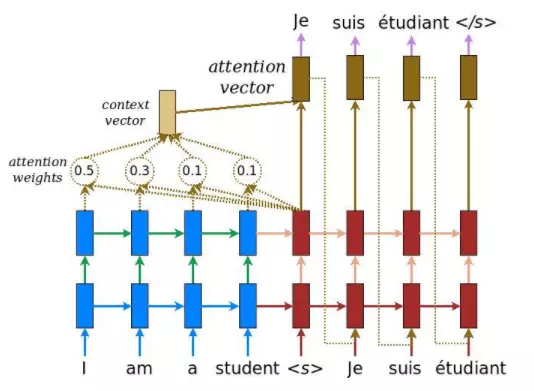

**Quy trình Luong Attention (Mapping với hình ảnh)**

**1. Chuẩn bị Inputs**

* **Trên hình:**

- Là các khối **màu xanh dương** (Encoder Outputs - h_s - giống với h_i trong bahdaunau attention - chỉ là đổi tên)
- Khối **màu đỏ** (Decoder Hidden State - h_t - giống với s_t trong bahdaunau attention - chỉ là đổi tên).

Vậy tại sao Bahdanau dùng (sₜ, hᵢ) còn Luong dùng (hₜ, hₛ)?

Khác biệt KHÔNG phải ở biến, mà ở **cách tính score**

---

> Bahdanau (additive)

$$
e_{t,i} = v^\top \tanh(W_s s_t + W_h h_i)
$$

* sₜ và hᵢ **được trộn phi tuyến**
* “suy nghĩ rồi mới so khớp”

---

> Luong (multiplicative)

$$
e_{t,s} = h_t^\top W h_s
$$

* hₜ và hₛ **nhân trực tiếp**
* “so khớp nhanh, gọn”

Nên paper đổi ký hiệu để nhấn mạnh decoder hidden **được dùng trực tiếp** để so khớp


* **Lưu ý:** Luong sử dụng trạng thái ẩn của bước *hiện tại* (khối màu đỏ đang xét) để tính toán.

**2. Tính Scores & Softmax (Alignment)**

* **Trên hình:** Tương ứng với các đường nét đứt và các **vòng tròn số** (0.5, 0.3, 0.1...).
* **Quy trình:**
* Lấy Decoder Hidden (Đỏ) nhân với Encoder Outputs (Xanh) qua ma trận trọng số W.
* Kết quả đưa qua Softmax để ra các con số trong vòng tròn (tổng = 1).
* **Ý nghĩa:** Số càng lớn (ví dụ 0.5) nghĩa là Decoder đang "nhìn" vào từ đó kỹ nhất (như từ "I" được chú ý 50%).



```python
scores = torch.bmm(query, keys.transpose(1, 2))
attn_weights = torch.softmax(scores, dim=1) # Ra các số 0.5, 0.3...

```

**3. Tính Context Vector**

* **Trên hình:** Chính là **khối màu vàng** (`context vector`).
* **Quy trình:** Nhân các giá trị trong vòng tròn (Weights) với các khối màu xanh (Encoder) rồi cộng lại.
* **Ý nghĩa:** Đây là "bản tóm tắt" của câu nguồn, tập trung vào những từ quan trọng nhất cho bước dịch hiện tại.

```python
context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)

```

**4. Tính Attentional Vector (Đầu ra cuối cùng)**

* **Trên hình:** Là mũi tên nối khối vàng (Context) và khối đỏ (Hidden) đi lên **khối màu nâu** (`Je`, `suis`...).
* **Quy trình:** Nối (Concat) `Context Vector` (Vàng) với `Decoder Hidden` (Đỏ) \rightarrow qua hàm Tanh \rightarrow Dự đoán từ tiếp theo (Nâu).
* **Code:** Đây là bước tổng hợp cuối cùng để mô hình quyết định từ vựng đầu ra.

```python
concat_input = torch.cat((decoder_hidden, context), 1)
attn_hidden = torch.tanh(self.wc(concat_input)) # Ra vector để dự đoán từ (Khối nâu)

```

In [151]:
import torch

class LuongAttention(nn.Module):
    """
    Cài đặt cơ chế Luong Attention (hàm score dạng General).
    Công thức:
        Score(h_t, h_s) = h_t^T * W * h_s
    """
    def __init__(self, hidden_size):
        super(LuongAttention, self).__init__()
        # Ma trận trọng số W dùng trong Luong attention - chỉ cần 1 ma trận
        self.W = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        """
        Hàm forward cho tầng attention.

        Tham số:
            decoder_hidden:  Trạng thái ẩn của decoder tại timestep hiện tại
                             [batch_size, hidden_size]
            encoder_outputs: Các hidden states của encoder tại mọi timestep
                             [batch_size, src_len, hidden_size]
            mask:            Mask padding (1 = token thật, 0 = PAD)
                             [batch_size, src_len]

        Trả về:
            context:         Vector ngữ cảnh (tổng có trọng số)
                             [batch_size, hidden_size]
            attn_weights:    Trọng số attention cho từng token nguồn
                             [batch_size, src_len]
        """

        # 1. Chiếu Encoder Outputs (Keys) và chuẩn bị Query
        # Keys: các encoder hidden states sau khi chiếu qua W
        # Shape: [batch_size, src_len, hidden_size]
        keys = self.W(encoder_outputs)

        # Query: decoder hidden state hiện tại
        # Shape: [batch_size, 1, hidden_size]
        query = decoder_hidden.unsqueeze(1)

        # 2. Tính Alignment Scores (General Score)
        # Nhân ma trận theo batch: Query @ Keys^T
        # [batch, 1, hidden] @ [batch, hidden, src_len]
        # -> [batch, 1, src_len]
        scores = torch.bmm(query, keys.transpose(1, 2))

        # Bỏ chiều dư thừa: [batch_size, src_len]
        scores = scores.squeeze(1)

        # 3. Áp dụng Mask
        if mask is not None:
            # Gán -infinity cho các vị trí PAD để attention không nhìn vào đó
            scores = scores.masked_fill(mask == 0, -1e9)

        # 4. Tính Attention Weights và Context Vector
        # Chuẩn hóa scores thành xác suất (softmax)
        # Shape: [batch_size, src_len]
        attn_weights = torch.softmax(scores, dim=1)

        # Tính tổng có trọng số của encoder outputs
        # [batch, 1, src_len] @ [batch, src_len, hidden]
        # -> [batch, 1, hidden]
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)

        # Bỏ chiều dư thừa -> [batch_size, hidden_size]
        context = context.squeeze(1)

        return context, attn_weights

### 3.3 Luong Decoder 3-layer LSTM

In [152]:
import torch
import torch.nn as nn

class DecoderLuong(nn.Module):
    """
    Kiến trúc Decoder sử dụng Luong Attention kết hợp với cơ chế Input Feeding.
    Tham khảo: "Effective Approaches to Attention-based Neural Machine Translation"
    """
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_size=256,
        num_layers=3,
        dropout=0.3
    ):
        super(DecoderLuong, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Tầng embedding: ánh xạ chỉ số token sang vector liên tục
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        # Tầng LSTM cho decoder
        # Lưu ý: input_size = embedding_dim + hidden_size
        # do sử dụng Input Feeding (nối embedding hiện tại với attentional vector của bước trước)
        self.lstm = nn.LSTM(
            input_size=embedding_dim + hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=(dropout if num_layers > 1 else 0.0)
        )

        # Các thành phần cho Attention và tầng output
        self.attention = LuongAttention(hidden_size)

        # Tầng kết hợp Context Vector và Decoder Hidden State
        self.wc = nn.Linear(hidden_size * 2, hidden_size)

        # Tầng chiếu ra không gian từ vựng
        self.fc_out = nn.Linear(hidden_size, vocab_size)

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        input_token,
        hidden,
        cell,
        encoder_outputs,
        pre_attn_hidden,
        mask=None
    ):
        """
        Hàm forward cho một timestep của decoder.

        Tham số:
            input_token:     Token hiện tại của decoder
                             [batch, 1]
            hidden:          Hidden state của decoder ở bước trước
                             [num_layers, batch, hidden]
            cell:            Cell state của decoder ở bước trước
                             [num_layers, batch, hidden]
            encoder_outputs: Các hidden states của encoder
                             [batch, src_len, hidden]
            pre_attn_hidden: Attentional vector ở timestep t-1 (dùng cho Input Feeding)
                             [batch, 1, hidden]
            mask:            Mask padding của câu nguồn
                             [batch, src_len]
        """

        # Lấy embedding cho token hiện tại
        # [batch, 1] -> [batch, 1, embedding_dim]
        embedded = self.embedding(input_token)
        embedded = self.dropout(embedded)

        # Cơ chế Input Feeding:
        # Nối embedding hiện tại với attentional vector của bước trước
        # [batch, 1, embedding_dim] + [batch, 1, hidden]
        # -> [batch, 1, embedding_dim + hidden]
        rnn_input = torch.cat([embedded, pre_attn_hidden], dim=2)

        # Chạy một bước LSTM
        # rnn_output: hidden state của layer trên cùng tại timestep hiện tại
        # Shape: [batch, 1, hidden]
        rnn_output, (hidden, cell) = self.lstm(rnn_input, (hidden, cell))

        # Lấy hidden state của layer trên cùng để làm query cho attention
        # [num_layers, batch, hidden] -> [batch, hidden]
        curr_hidden = hidden[-1]

        # Tính context vector bằng Luong attention
        # context: Tổng có trọng số của encoder outputs
        # attn_weights: Phân phối attention trên câu nguồn
        context, attn_weights = self.attention(curr_hidden, encoder_outputs, mask)

        # Tạo attentional vector h_tilde_t
        # Nối context vector và hidden state hiện tại
        # [batch, hidden] + [batch, hidden] -> [batch, 2 * hidden]
        concat_input = torch.cat((context, curr_hidden), dim=1)

        # Áp dụng Linear + Tanh (theo Eq. (5) trong paper Luong)
        # [batch, 2 * hidden] -> [batch, hidden]
        attn_hidden = torch.tanh(self.wc(concat_input))

        # Chiếu attentional vector ra không gian từ vựng để dự đoán token tiếp theo
        # [batch, hidden] -> [batch, vocab_size]
        logits = self.fc_out(attn_hidden)

        # Trả về attn_hidden (thêm chiều) để dùng cho Input Feeding ở timestep tiếp theo
        return logits, hidden, cell, attn_weights, attn_hidden.unsqueeze(1)

### 3.4 Seq2Seq wrapper ghép Encoder + Decoder

In [153]:
import random
import torch
import torch.nn as nn


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx # Lưu lại ID của token PAD để tạo mask

    def create_mask(self, src):
        # src: [batch, src_len]
        # Tạo mask: True ở nơi có từ, False ở nơi là PAD
        mask = (src != self.pad_idx)
        return mask

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)

        # --- TẠO MASK ---
        mask = self.create_mask(src) # [batch, src_len]

        encoder_outputs, hidden, cell = self.encoder(src)

        decoder_input = tgt[:, 0].unsqueeze(1)
        attn_hidden = torch.zeros(batch_size, 1, self.decoder.hidden_size).to(src.device)

        outputs = []

        for t in range(1, tgt_len):
            logits, hidden, cell, _, attn_hidden = self.decoder(
                decoder_input,
                hidden,
                cell,
                encoder_outputs,
                attn_hidden,
                mask   # <--- TRUYỀN MASK VÀO DECODER
            )

            outputs.append(logits.unsqueeze(1))

            use_teacher_forcing = random.random() < teacher_forcing_ratio
            top_token = logits.argmax(dim=1)
            decoder_input = (tgt[:, t].unsqueeze(1) if use_teacher_forcing else top_token.unsqueeze(1))

        return torch.cat(outputs, dim=1)

    @torch.no_grad()
    def predict(self, src, max_len=100):
        self.eval()
        device = src.device
        batch_size = src.size(0)

        # --- TẠO MASK CHO PREDICT ---
        mask = self.create_mask(src)

        encoder_outputs, hidden, cell = self.encoder(src)
        decoder_input = torch.full((batch_size, 1), BOS_ID, dtype=torch.long, device=device)
        attn_hidden = torch.zeros(batch_size, 1, self.decoder.hidden_size).to(device)

        outputs = []
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

        for _ in range(max_len):
            logits, hidden, cell, _, attn_hidden = self.decoder(
                decoder_input, hidden, cell, encoder_outputs, attn_hidden, mask
            )

            top1 = logits.argmax(dim=1)
            outputs.append(top1.unsqueeze(1))
            decoder_input = top1.unsqueeze(1)

            finished |= (top1 == EOS_ID)
            if finished.all(): break

        return torch.cat(outputs, dim=1)

In [154]:
SRC_VOCAB_SIZE = len(src_token2id)
TGT_VOCAB_SIZE = len(tgt_token2id)

encoder = Encoder(
    vocab_size=SRC_VOCAB_SIZE,
    embed_dim=256,
    hidden_size=256,
    num_layers=3
)

decoder = DecoderLuong(
    vocab_size=TGT_VOCAB_SIZE,
    embedding_dim=256,
    hidden_size=256,
    num_layers=3
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Seq2Seq(encoder, decoder, pad_idx=PAD_ID).to(device)

batch = next(iter(train_loader))
out = model(
    batch["src"].to(device),
    batch["tgt"].to(device)
)

print(out.shape)

torch.Size([64, 84, 4253])


## 4. TRAINING LOOP (Seq2Seq + Adam)

### 4.1 Chuẩn bị loss & optimizer

In [155]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

> Lưu ý quan trọng: ignore `<pad>` là bắt buộc. Nếu không, model sinh `<pad>` sớm => câu toàn kí tự `<pad>` => ROUGE-L tụt (do thành phần LCS prediction + recall tụt). Do thông thường kí hiệu `<pad>` xuất hiện rất nhiều - do câu ngắn chiếm đa số (ngắn hơn tgt_len), nếu không ignore `<pad>`, model sẽ cố gắng an toàn sinh ra toàn các `<pad>` sớm, gây mất nhiều từ quan trọng và câu bị ngắn đi.

### 4.2 Hàm train 1 epoch

In [156]:
def train_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion,
    teacher_forcing_ratio=0.5,
    device="cpu"
):
    model.train()
    total_loss = 0.0

    for batch in dataloader:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)

        optimizer.zero_grad()

        # Forward: Seq2Seq
        outputs = model(
            src,
            tgt,
            teacher_forcing_ratio=teacher_forcing_ratio
        )
        # outputs: (B, tgt_len-1, vocab_size)

        output_dim = outputs.size(-1)

        # Shift target: bỏ <BOS>
        outputs = outputs.reshape(-1, output_dim)
        targets = tgt[:, 1:].reshape(-1)

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

- `tgt[:, 1:]` là label

- `<bos>` không được tính loss

- `<pad>` bị ignore

### 4.3 Hàm validation (KHÔNG teacher forcing)

In [157]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device="cpu"):
    model.eval()
    total_loss = 0.0

    for batch in dataloader:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)

        outputs = model(src, tgt, teacher_forcing_ratio=0.0)

        output_dim = outputs.size(-1)
        outputs = outputs.reshape(-1, output_dim)
        targets = tgt[:, 1:].reshape(-1)

        loss = criterion(outputs, targets)
        total_loss += loss.item()

    return total_loss / len(dataloader)

### 4.4 Hàm tính ROUGE-L

In [158]:
from rouge_score import rouge_scorer
from tqdm import tqdm

@torch.no_grad()
def evaluate_rouge_l(model, dataloader, device):
    model.eval()
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

    scores = []

    for batch in tqdm(dataloader, desc="Evaluating ROUGE-L"):
        src = batch["src"].to(device)
        tgt = batch["tgt"]  # để decode, không cần .to(device)

        preds = model.predict(src)  # [B, pred_len]

        for i in range(src.size(0)):
            pred_sentence = decode_ids_to_sentence(preds[i].cpu().tolist())
            tgt_sentence  = decode_ids_to_sentence(tgt[i, 1:].tolist())  # bỏ <BOS>

            score = scorer.score(tgt_sentence, pred_sentence)
            scores.append(score["rougeL"].fmeasure)

    return sum(scores) / len(scores)

### 4.5 Hàm decode - chuyển list token ids thành câu string


In [159]:
def decode_ids_to_sentence(ids, id2token=tgt_id2token):
    """
    Chuyển list token ids => câu string

    Args:
        ids: List[int]
    Returns:
        sentence: str
    """
    tokens = []
    for idx in ids:
        if idx == EOS_ID:
            break
        if idx in (PAD_ID, BOS_ID):
            continue
        tokens.append(id2token.get(idx, "<unk>"))

    return " ".join(tokens)

In [160]:
batch = next(iter(dev_loader))
preds = model.predict(batch["src"].to(device))

print("PRED:", decode_ids_to_sentence(preds[0].cpu().tolist()))
print("GT  :", decode_ids_to_sentence(batch["tgt"][0, 1:].tolist()))

PRED: cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber cyber
GT  : vào chủ nhật ngày <unk> cơn bão <unk> một trong những cơn bão mạnh nhất được ghi nhận ở đại tây dương với sức gió <unk> <unk> đổ bộ vào đảo great <unk> miền bắc <unk>


### 4.6 Training loop tổng

In [161]:
# tăng tốc training
torch.backends.cudnn.benchmark = True

In [162]:
best_rouge_l = -1.0
BEST_MODEL_PATH = "best_seq2seq_rougeL.pt"

train_losses = []
val_losses = []
val_rouge_ls = []

In [163]:
N_EPOCHS = 15

for epoch in range(1, N_EPOCHS + 1):

    # ---- scheduled teacher forcing ----
    teacher_forcing_ratio = max(0.5 - epoch * 0.05, 0.1)

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        teacher_forcing_ratio=teacher_forcing_ratio,
        device=device
    )

    val_loss = evaluate(
        model,
        dev_loader,
        criterion,
        device=device
    )

    rouge_l = evaluate_rouge_l(
        model,
        dev_loader,
        device=device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_rouge_ls.append(rouge_l)

    # ---- SAVE BEST MODEL BY ROUGE-L ----
    if rouge_l > best_rouge_l:
        best_rouge_l = rouge_l
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        improved = "🔥 saved"
    else:
        improved = ""

    print(f"Epoch {epoch:02d}")
    print(f"  Train loss: {train_loss:.4f}")
    print(f"  Val   loss: {val_loss:.4f}")
    print(f"  ROUGE-L   : {rouge_l:.4f} {improved}")

Evaluating ROUGE-L: 100%|██████████| 32/32 [00:03<00:00,  9.47it/s]


Epoch 01
  Train loss: 6.3448
  Val   loss: 6.3743
  ROUGE-L   : 0.1647 🔥 saved


Evaluating ROUGE-L: 100%|██████████| 32/32 [00:02<00:00, 12.57it/s]


Epoch 02
  Train loss: 6.2051
  Val   loss: 6.3489
  ROUGE-L   : 0.1773 🔥 saved


Evaluating ROUGE-L: 100%|██████████| 32/32 [00:02<00:00, 11.79it/s]


...

Epoch 13
  Train loss: 4.5480
  Val   loss: 5.8347
  ROUGE-L   : 0.3364 


Evaluating ROUGE-L: 100%|██████████| 32/32 [00:03<00:00,  9.13it/s]


Epoch 14
  Train loss: 4.4295
  Val   loss: 5.8968
  ROUGE-L   : 0.3436 🔥 saved


Evaluating ROUGE-L: 100%|██████████| 32/32 [00:04<00:00,  7.01it/s]

Epoch 15
  Train loss: 4.3054
  Val   loss: 5.9519
  ROUGE-L   : 0.3454 🔥 saved


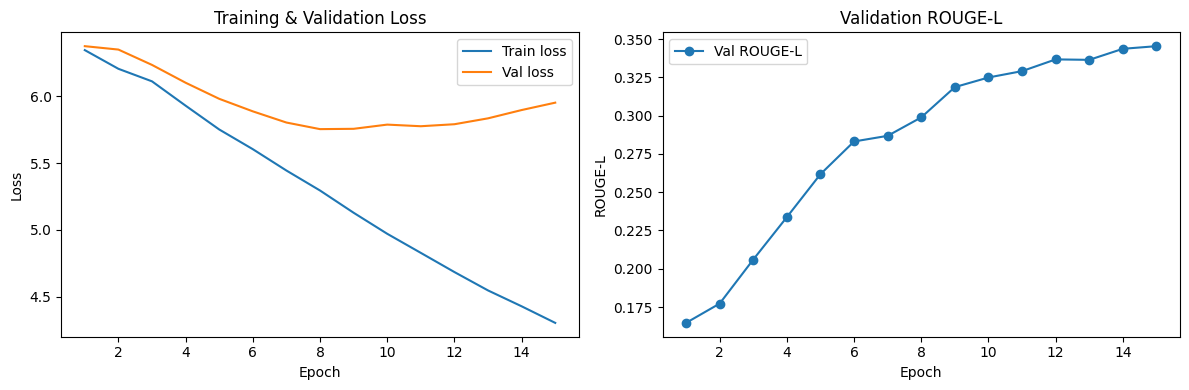

In [164]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

# ---- Loss ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train loss")
plt.plot(epochs, val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

# ---- ROUGE-L ----
plt.subplot(1, 2, 2)
plt.plot(epochs, val_rouge_ls, marker="o", label="Val ROUGE-L")
plt.xlabel("Epoch")
plt.ylabel("ROUGE-L")
plt.title("Validation ROUGE-L")
plt.legend()

plt.tight_layout()
plt.show()

>Val loss tăng trong khi training loss giảm (overfiting), tuy nhiên ROUGE-L vẫn có dấu hiệu tiếp tục tăng nếu train thêm epochs.

## 5. Inference + ROUGE-L evaluation

In [165]:
test_dataset = TranslationDataset(
    test_data,
    src_token2id,
    tgt_token2id
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [166]:
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

test_rouge_l = evaluate_rouge_l(
    model,
    test_loader,
    device=device
)

print(f"Test ROUGE-L: {test_rouge_l:.4f}")

Evaluating ROUGE-L: 100%|██████████| 63/63 [00:04<00:00, 13.29it/s]

Test ROUGE-L: 0.3566


> Test ROUGE-L: 0.3566 - kém hơn bahdaunau attention 0.015, 

>Nhưng luong attention lại training nhanh hơn khá nhiều, do cơ chế tính điểm đơn giản hơn, sử dụng phép nhân ma trận trực tiếp (multiplicative attention) thay vì hàm phi tuyến như Bahdanau attention.

In [167]:
# In vài câu dự đoán để quan sát chất lượng dịch
model.eval()

num_samples = 5
batch = next(iter(dev_loader))

src = batch["src"].to(device)
tgt = batch["tgt"]

preds = model.predict(src)

print("=" * 80)
for i in range(num_samples):
    src_sentence = decode_ids_to_sentence(
        batch["src"][i].tolist(),
        id2token=src_id2token   # vocab tiếng Anh
    )
    tgt_sentence = decode_ids_to_sentence(
        tgt[i, 1:].tolist(),    # bỏ <BOS>
        id2token=tgt_id2token
    )
    pred_sentence = decode_ids_to_sentence(
        preds[i].cpu().tolist(),
        id2token=tgt_id2token
    )

    print(f"[SRC ] {src_sentence}")
    print(f"[GT  ] {tgt_sentence}")
    print(f"[PRED] {pred_sentence}")
    print("-" * 80)

[SRC ] hurricane <unk> one of the most powerful <unk> ever recorded in the atlantic ocean made <unk> as a category 5 storm on great <unk> island in the northern <unk> on sunday morning september 1 <unk>
[GT  ] vào chủ nhật ngày <unk> cơn bão <unk> một trong những cơn bão mạnh nhất được ghi nhận ở đại tây dương với sức gió <unk> <unk> đổ bộ vào đảo great <unk> miền bắc <unk>
[PRED] michael <unk> một trong trong lớn lớn nhất nhất được được được trong trong ở đông tộc <unk> <unk> <unk> <unk> một một mùi mùi mùi mùi <unk> <unk> <unk> <unk> trong trong trong đầu ngày ngày
--------------------------------------------------------------------------------
[SRC ] <unk> is especially dangerous due to its slow movement high wind speeds and heavy <unk>
[GT  ] bão <unk> đặc biệt nguy hiểm vì nó di chuyển chậm có tốc độ gió cao và gây mưa lớn
[PRED] <unk> là là là gian gian gian gian gian mất mất <unk> <unk> <unk> và và và và
---------------------------------------------------------------------------